CMPS 6790 Final Project - Kyle Parfait

Milestone 1

For my project, I am considering working with one of two datasets. The first pertains to student academic performance. This dataset includes a lot of information that would be valuable for analysis, like AI usage, hours of sleep, standardized test scores, and even parental involvement. The questions that immediately come to mind with this dataset deal with AI usage affecting overall performance and mental health and sleep.

        How does the use of AI affect students’ overall performance? 
        What other factors, like online course hours and socioeconomic factors, make the biggest differences? 
        How does high academic performance relate to mental health and adequate sleep? 

The columns in this dataset are pretty expansive, so there’s a lot of room for exploration of other questions and visuals. Student performance is declining; the NAEP shows a long-term decline in mathematics and reading. As someone with educators in my family, I am personally curious to explore what factors attribute to this decline. Many cite lack of parental support, too much social media usage, poor mental health, and relying on AI to complete work without comprehending concepts. 

The other dataset I am considering deals with social media user analysis. Many people can understand the draw to social media, and many of us spend too much time on it, or at least feel that we do. This dataset contains information related to sleep hours, time spent exercising weekly, employment status, and education level. I believe a good bit of information can be derived from this route. The questions I would aim to answer here relate to users’ physicality and socioeconomic statuses relating to usage. 

        How does increased time on social media relate to physical health and physical activity? 
        Is there a relationship between economic status, income level, and social media usage?

Of these two datasets, I am strongly leaning toward the first, student performance. This dataset captures a lot more information, so there is a good bit of flexibility with the project. Even if I completely change my questions, there are still other good options.

Considering ETL, I am going to use the CSVs that I’ve downloaded locally and load them into pandas DataFrames. I still need to verify that there are not missing values in any of the rows and really narrow down the most important columns in both datasets. Numerical values like sleep hours would be standardized, and I need to consider how to transform the data. Columns like parental education and other socioeconomics would need to be encoded since they’re categorical. My plan is to begin with distribution plots, then probably adding regression lines. Correlation heatmaps could also help to visualize the strongest correlations.


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Dataset - Student Academic Performance

student_df = pd.read_csv("../data/student_academic_performance.csv")
student_df.head()

,math_score,science_score,english_score,history_score,computer_score,attendance_rate,assignment_avg,quiz_avg,project_score,previous_gpa,...,final_gpa,standardized_exam_score,improvement_next_term,dropout_risk_score,learning_efficiency,stress_index,pass_fail,honors_flag,at_risk_flag,top_performer_flag
0,62.456370,88.073740,72.526180,76.06144,92.64728,1.000000,104.827740,68.451580,81.24903,2.890757,...,4.000000,78.581310,2.040133,0.001787,-1.235061,5.918975,1,0,0,0
1,56.778812,65.597540,69.882500,69.57163,71.62665,0.729115,51.119255,80.345620,81.51603,2.693535,...,2.910472,52.727460,-1.696975,0.679032,1.416623,6.216345,1,0,1,0
2,78.238100,69.305824,76.588830,75.70467,67.68652,0.634656,47.222202,72.382280,58.76614,2.721305,...,2.412240,73.162010,-1.354060,0.756908,0.684399,5.116631,1,0,1,0
3,86.619550,81.867950,87.423485,76.50009,86.60630,0.811508,69.160630,63.451378,49.04596,3.366405,...,3.244543,85.844340,1.749234,0.962086,-1.249343,3.829115,1,0,1,0
4,65.569824,76.941990,67.950760,67.18360,73.40711,0.786856,44.262510,64.553490,48.36373,2.618776,...,2.294958,56.980495,-0.747696,0.698020,-1.555532,4.509945,1,0,1,0


In [ ]:
# There are quite a bit of columns that could give some very good information about academic performance.
list(student_df.columns)

['math_score',
 'science_score',
 'english_score',
 'history_score',
 'computer_score',
 'attendance_rate',
 'assignment_avg',
 'quiz_avg',
 'project_score',
 'previous_gpa',
 'study_hours_daily',
 'revision_hours',
 'age',
 'gender',
 'urban_flag',
 'family_size',
 'parent_education',
 'family_income',
 'sleep_hours',
 'physical_activity',
 'screen_time',
 'junk_food_freq',
 'bmi',
 'illness_days',
 'mental_stress',
 'sleep_quality',
 'internet_access',
 'private_tuition',
 'tuition_hours',
 'study_room',
 'parent_involvement',
 'scholarship_flag',
 'part_time_job_hours',
 'financial_stress',
 'online_course_hours',
 'lms_login_frequency',
 'coding_practice_hours',
 'ai_tool_usage',
 'digital_literacy',
 'video_watch_hours',
 'forum_participation',
 'device_availability',
 'final_gpa',
 'standardized_exam_score',
 'improvement_next_term',
 'dropout_risk_score',
 'learning_efficiency',
 'stress_index',
 'pass_fail',
 'honors_flag',
 'at_risk_flag',
 'top_performer_flag']

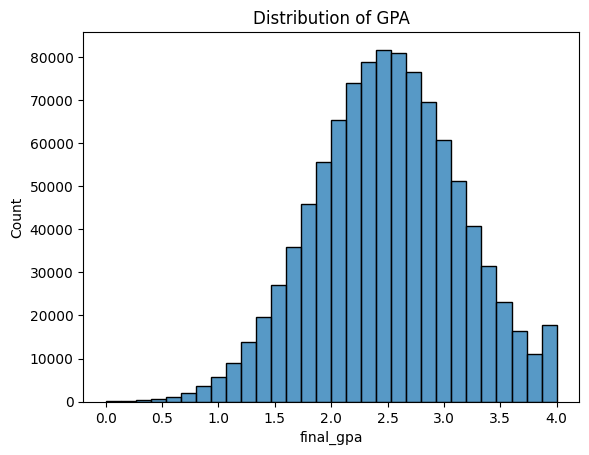

In [ ]:
# Visualization of GPA Distribution

sns.histplot(student_df["final_gpa"], bins=30)
plt.title("Distribution of GPA")
plt.show()

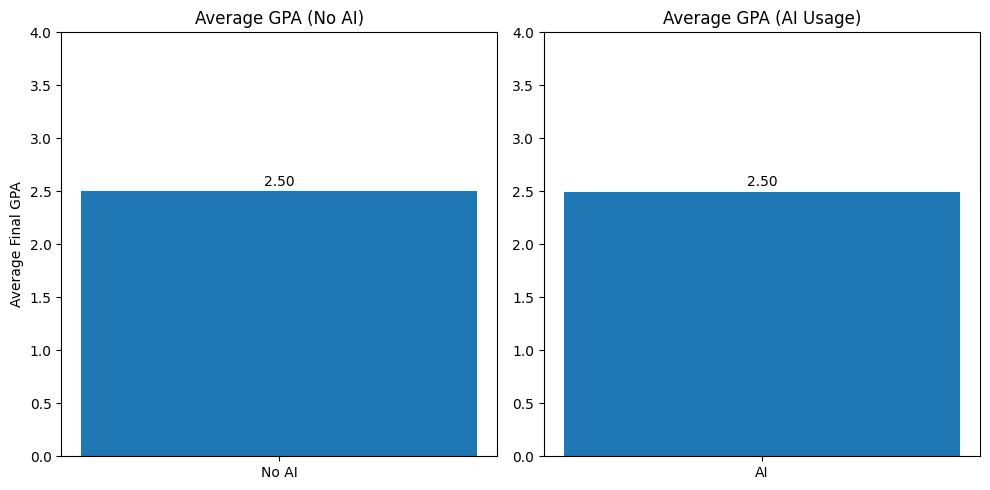

In [ ]:
# These charts show the GPAs of students that have not used AI, versus the ones that have. 

mean_no_ai = student_df[student_df["ai_tool_usage"] == 0]["final_gpa"].mean()
mean_ai = student_df[student_df["ai_tool_usage"] == 1]["final_gpa"].mean()
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# No AI
axes[0].bar("No AI", mean_no_ai)
axes[0].set_ylim(0, 4)
axes[0].set_ylabel("Average Final GPA")
axes[0].set_title("Average GPA (No AI)")
axes[0].text(0, mean_no_ai + 0.05, f"{mean_no_ai:.2f}", ha='center')

# AI
axes[1].bar("AI", mean_ai)
axes[1].set_ylim(0, 4)
axes[1].set_title("Average GPA (AI Usage)")
axes[1].text(0, mean_ai + 0.05, f"{mean_ai:.2f}", ha='center')

plt.tight_layout()
plt.show()

In [ ]:
# Dataset - Social Media User Analysis

user_df = pd.read_csv("../data/instagram_users_lifestyle.csv")
user_df.head()

,user_id,app_name,age,gender,country,urban_rural,income_level,employment_status,education_level,relationship_status,...,last_login_date,average_session_length_minutes,content_type_preference,preferred_content_theme,privacy_setting_level,two_factor_auth_enabled,biometric_login_used,linked_accounts_count,subscription_status,user_engagement_score
0,1,Instagram,51,Female,India,Rural,High,Retired,Bachelor’s,Single,...,2025-11-02,5.0,Mixed,Tech,Private,Yes,No,0,Free,7.83
1,2,Instagram,64,Female,United Kingdom,Urban,Middle,Full-time employed,Other,Divorced,...,2025-03-22,14.8,Photos,Fashion,Public,No,No,3,Free,1.43
2,3,Instagram,41,Female,Canada,Urban,Middle,Student,Bachelor’s,In a relationship,...,2025-08-10,5.0,Mixed,Other,Public,Yes,Yes,1,Free,9.67
3,4,Instagram,27,Non-binary,South Korea,Urban,Middle,Unemployed,Master’s,In a relationship,...,2025-03-31,25.9,Stories,Tech,Private,No,No,1,Free,0.94
4,5,Instagram,55,Male,India,Urban,Upper-middle,Full-time employed,Bachelor’s,Single,...,2025-03-19,13.1,Videos,Food,Public,Yes,No,0,Free,1.03


In [ ]:
# This dataset also has very valuable information about social media users and their habits.
list(user_df.columns)

['user_id',
 'app_name',
 'age',
 'gender',
 'country',
 'urban_rural',
 'income_level',
 'employment_status',
 'education_level',
 'relationship_status',
 'has_children',
 'exercise_hours_per_week',
 'sleep_hours_per_night',
 'diet_quality',
 'smoking',
 'alcohol_frequency',
 'perceived_stress_score',
 'self_reported_happiness',
 'body_mass_index',
 'blood_pressure_systolic',
 'blood_pressure_diastolic',
 'daily_steps_count',
 'weekly_work_hours',
 'hobbies_count',
 'social_events_per_month',
 'books_read_per_year',
 'volunteer_hours_per_month',
 'travel_frequency_per_year',
 'daily_active_minutes_instagram',
 'sessions_per_day',
 'posts_created_per_week',
 'reels_watched_per_day',
 'stories_viewed_per_day',
 'likes_given_per_day',
 'comments_written_per_day',
 'dms_sent_per_week',
 'dms_received_per_week',
 'ads_viewed_per_day',
 'ads_clicked_per_day',
 'time_on_feed_per_day',
 'time_on_explore_per_day',
 'time_on_messages_per_day',
 'time_on_reels_per_day',
 'followers_count',
 'fol

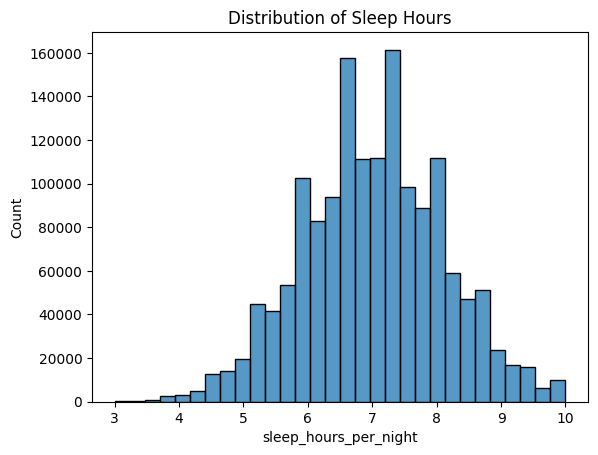

In [ ]:
# Visualization of Sleep Hours Per Night

sns.histplot(user_df["sleep_hours_per_night"], bins=30)
plt.title("Distribution of Sleep Hours")
plt.show()

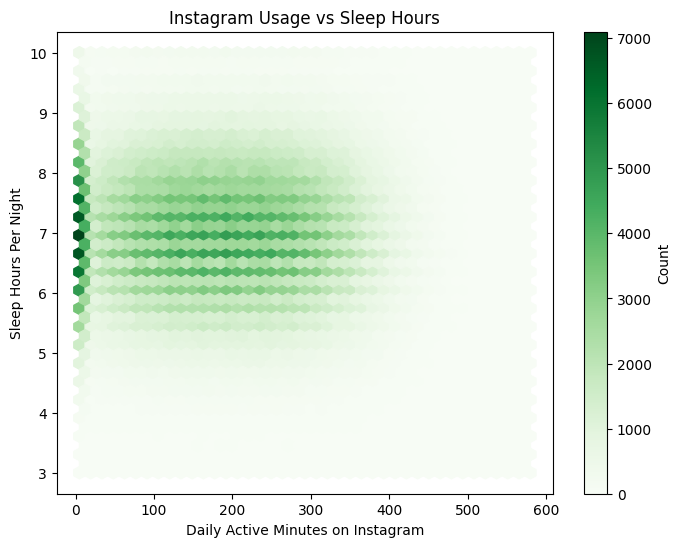

In [ ]:
# Hexbin for Sleep Hours and Minutes of Instagram Usage

plt.figure(figsize=(8,6))

plt.hexbin(
    user_df["daily_active_minutes_instagram"],
    user_df["sleep_hours_per_night"],
    gridsize=40,
    cmap="Greens"
)

plt.colorbar(label="Count")
plt.xlabel("Daily Active Minutes on Instagram")
plt.ylabel("Sleep Hours Per Night")
plt.title("Instagram Usage vs Sleep Hours")

plt.show()